# Improving Your Seq2Seq Translator: BLEU Evaluation & Beam Search Decoding
### EN→RU Seq2Seq — From Greedy Decoding to Beam Search with BLEU Scoring
> Built from scratch: no NLTK/sacrebleu for BLEU, pure PyTorch beam search.

## 1. Imports & Device Setup

In [1]:
import re, math, time, random, unicodedata
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[DEVICE] Using: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'[GPU]    {torch.cuda.get_device_name(0)}')

[DEVICE] Using: cuda
[GPU]    NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Hyperparameters & Special Tokens

In [2]:
# ── All hyperparameters — must match the trained model ────────────────────────
EMBED_DIM      = 256
HIDDEN_DIM     = 1024
NUM_LAYERS     = 2
DROPOUT        = 0.3
BATCH_SIZE     = 128
MAX_VOCAB_SIZE = 15_000
MAX_LEN        = 30
VAL_SPLIT      = 0.1
MAX_PAIRS      = 50_000
TEACHER_FORCING = 0.3

# Special tokens
PAD_TOKEN = '<pad>'; PAD_IDX = 0
SOS_TOKEN = '<sos>'; SOS_IDX = 1
EOS_TOKEN = '<eos>'; EOS_IDX = 2
UNK_TOKEN = '<unk>'; UNK_IDX = 3

print('[HYPERPARAMS] Loaded.')
print(f'  Embed dim  : {EMBED_DIM}')
print(f'  Hidden dim : {HIDDEN_DIM}')
print(f'  Num layers : {NUM_LAYERS}')
print(f'  Dropout    : {DROPOUT}')

[HYPERPARAMS] Loaded.
  Embed dim  : 256
  Hidden dim : 1024
  Num layers : 2
  Dropout    : 0.3


## 3. Rebuild Vocabulary & Load Dataset
We rebuild the same vocabulary as during training so indices are consistent.

In [3]:
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def clean_text(text, is_russian=False):
    if not is_russian:
        text = unicode_to_ascii(text.lower())
    else:
        text = text.lower()
    text = re.sub(r"[^а-яёa-z\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def load_pairs(filepath, max_pairs=None, max_len=MAX_LEN):
    pairs = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2: continue
            eng = clean_text(parts[0], is_russian=False)
            rus = clean_text(parts[1], is_russian=True)
            if 2 <= len(eng.split()) <= max_len and 2 <= len(rus.split()) <= max_len:
                pairs.append((eng, rus))
            if max_pairs and len(pairs) >= max_pairs:
                break
    return pairs

class Vocabulary:
    def __init__(self, name, max_size=MAX_VOCAB_SIZE):
        self.name     = name
        self.max_size = max_size
        self.word2idx = {PAD_TOKEN:0, SOS_TOKEN:1, EOS_TOKEN:2, UNK_TOKEN:3}
        self.idx2word = {0:PAD_TOKEN, 1:SOS_TOKEN, 2:EOS_TOKEN, 3:UNK_TOKEN}

    def build(self, sentences):
        counter = Counter(w for sent in sentences for w in sent.split())
        for word, _ in counter.most_common(self.max_size - 4):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word

    def encode(self, sentence):
        return [self.word2idx.get(w, UNK_IDX) for w in sentence.split()]

    def decode(self, indices):
        words = []
        for i in indices:
            w = self.idx2word.get(i, UNK_TOKEN)
            if w in (EOS_TOKEN, PAD_TOKEN): break
            if w != SOS_TOKEN: words.append(w)
        return ' '.join(words)

    def __len__(self): return len(self.word2idx)


# ── Load and split data (same random seed = same split as training) ───────────
random.seed(42)
DATA_PATH = 'rus.txt'
pairs = load_pairs(DATA_PATH, max_pairs=MAX_PAIRS)
random.shuffle(pairs)

val_size    = int(len(pairs) * VAL_SPLIT)
train_pairs = pairs[val_size:]
val_pairs   = pairs[:val_size]

# Build vocabularies from ALL pairs (same as training)
eng_vocab = Vocabulary('English')
rus_vocab = Vocabulary('Russian')
eng_vocab.build([p[0] for p in pairs])
rus_vocab.build([p[1] for p in pairs])

print(f'[DATA]   Total pairs : {len(pairs):,}')
print(f'[DATA]   Val pairs   : {len(val_pairs):,}')
print(f'[VOCAB]  English     : {len(eng_vocab):,} words')
print(f'[VOCAB]  Russian     : {len(rus_vocab):,} words')

[DATA]   Total pairs : 50,000
[DATA]   Val pairs   : 5,000
[VOCAB]  English     : 4,796 words
[VOCAB]  Russian     : 13,449 words


## 4. Rebuild & Load the Trained Seq2Seq Model

In [4]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers,
                                 batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        _, (hidden, cell) = self.lstm(embedded)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers,
                                 batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.fc        = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, trg_token, hidden, cell):
        trg_token = trg_token.unsqueeze(1)
        embedded  = self.dropout(self.embedding(trg_token))
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size     = src.shape[0]
        trg_len        = trg.shape[1]
        trg_vocab_size = self.decoder.fc.out_features
        outputs        = torch.zeros(batch_size, trg_len, trg_vocab_size).to(src.device)
        hidden, cell   = self.encoder(src)
        dec_input      = trg[:, 0]
        for t in range(1, trg_len):
            pred, hidden, cell = self.decoder(dec_input, hidden, cell)
            outputs[:, t, :]   = pred
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input   = trg[:, t] if use_teacher else pred.argmax(dim=1)
        return outputs


# ── Instantiate and load weights ─────────────────────────────────────────────
encoder = Encoder(len(eng_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
decoder = Decoder(len(rus_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
model   = Seq2Seq(encoder, decoder).to(DEVICE)

model.load_state_dict(torch.load('seq2seq_best.pt', map_location=DEVICE))
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'[MODEL]  Loaded seq2seq_best.pt')
print(f'[MODEL]  Total parameters: {total_params:,}')
print(f'[MODEL]  Encoder vocab: {len(eng_vocab):,}  |  Decoder vocab: {len(rus_vocab):,}')

[MODEL]  Loaded seq2seq_best.pt
[MODEL]  Total parameters: 45,751,689
[MODEL]  Encoder vocab: 4,796  |  Decoder vocab: 13,449


## 5. BLEU Implementation from Scratch
No external libraries — every function built manually.

**Why BLEU?** It measures n-gram overlap between hypothesis (model output) and reference (ground truth). Higher = better translation.

In [5]:
def get_ngrams(tokens, n):
    """
    Given a list of tokens and integer n, return a Counter of all n-grams.
    Example: get_ngrams(['the','cat','is'], 2)
             → Counter({('the','cat'):1, ('cat','is'):1})
    """
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    return Counter(ngrams)


def clipped_precision(hypothesis, reference, n):
    """
    Clipped n-gram precision:
    - Count how many n-grams in hypothesis also appear in reference
    - CLIP each n-gram count to how many times it appears in reference
      (prevents the model from gaming the score by repeating one good word)
    - Divide by total n-grams in hypothesis
    Returns 0.0 if hypothesis is too short.
    """
    hyp_ngrams = get_ngrams(hypothesis, n)
    ref_ngrams = get_ngrams(reference,  n)

    if sum(hyp_ngrams.values()) == 0:
        return 0.0

    # Clipped count: min(hypothesis count, reference count) for each ngram
    clipped_count = sum(
        min(count, ref_ngrams[ngram])
        for ngram, count in hyp_ngrams.items()
    )

    total_hyp_ngrams = sum(hyp_ngrams.values())
    return clipped_count / total_hyp_ngrams


def brevity_penalty(hypothesis, reference):
    """
    Penalizes translations that are shorter than the reference.
    BP = 1                        if len(hyp) >= len(ref)
    BP = exp(1 - len(ref)/len(hyp)) if len(hyp) <  len(ref)
    A very short hypothesis can achieve high precision trivially,
    so BP < 1 discourages this behavior.
    """
    c = len(hypothesis)   # hypothesis length
    r = len(reference)    # reference length

    if c == 0:
        return 0.0
    if c >= r:
        return 1.0
    return math.exp(1 - r / c)


def bleu_score(hypothesis, reference, max_n=4):
    """
    Compute BLEU score combining:
    1. Clipped precision for n = 1..max_n
    2. Geometric mean with uniform weights (1/max_n each)
       — computed in log space to prevent underflow
    3. Brevity penalty

    Returns 0.0 if any precision is 0 (standard BLEU behavior).
    """
    # Tokenize if strings are passed
    if isinstance(hypothesis, str):
        hypothesis = hypothesis.split()
    if isinstance(reference, str):
        reference = reference.split()

    bp = brevity_penalty(hypothesis, reference)
    if bp == 0.0:
        return 0.0

    # Compute log-precisions for n = 1..max_n
    log_precisions = []
    for n in range(1, max_n + 1):
        p = clipped_precision(hypothesis, reference, n)
        if p == 0.0:
            return 0.0   # one zero precision → BLEU = 0
        log_precisions.append(math.log(p))

    # Weighted geometric mean in log space → exp(mean of logs)
    score = bp * math.exp(sum(log_precisions) / max_n)
    return score


print('[BLEU] Functions defined: get_ngrams, clipped_precision, brevity_penalty, bleu_score')

[BLEU] Functions defined: get_ngrams, clipped_precision, brevity_penalty, bleu_score


## 6. Verify BLEU Implementation
The assignment specifies an exact known test case. Our result must be ≈ 0.516.

In [6]:
# ── Known test case from the assignment ──────────────────────────────────────
hyp_test = "the match was postponed because of the snow"
ref_test = "the match was postponed because it was snowing"

hyp_tokens = hyp_test.split()
ref_tokens = ref_test.split()

# Step-by-step debug prints
print('[VERIFY] Hypothesis :', hyp_test)
print('[VERIFY] Reference  :', ref_test)
print()

for n in range(1, 5):
    p = clipped_precision(hyp_tokens, ref_tokens, n)
    hyp_ng = get_ngrams(hyp_tokens, n)
    ref_ng = get_ngrams(ref_tokens, n)
    print(f'  [{n}-gram]  hyp ngrams: {dict(hyp_ng)}')
    print(f'             ref ngrams: {dict(ref_ng)}')
    print(f'             clipped precision: {p:.4f}')
    print()

bp    = brevity_penalty(hyp_tokens, ref_tokens)
score = bleu_score(hyp_tokens, ref_tokens)

print(f'[VERIFY] Brevity Penalty  : {bp:.4f}  (hyp_len={len(hyp_tokens)}, ref_len={len(ref_tokens)})')
print(f'[VERIFY] BLEU Score       : {score:.4f}')
print(f'[VERIFY] Expected         : ~0.516')
print(f'[VERIFY] Status           : {"✓ PASS" if abs(score - 0.516) < 0.01 else "✗ FAIL — debug clipped_precision or brevity_penalty"}')

[VERIFY] Hypothesis : the match was postponed because of the snow
[VERIFY] Reference  : the match was postponed because it was snowing

  [1-gram]  hyp ngrams: {('the',): 2, ('match',): 1, ('was',): 1, ('postponed',): 1, ('because',): 1, ('of',): 1, ('snow',): 1}
             ref ngrams: {('the',): 1, ('match',): 1, ('was',): 2, ('postponed',): 1, ('because',): 1, ('it',): 1, ('snowing',): 1}
             clipped precision: 0.6250

  [2-gram]  hyp ngrams: {('the', 'match'): 1, ('match', 'was'): 1, ('was', 'postponed'): 1, ('postponed', 'because'): 1, ('because', 'of'): 1, ('of', 'the'): 1, ('the', 'snow'): 1}
             ref ngrams: {('the', 'match'): 1, ('match', 'was'): 1, ('was', 'postponed'): 1, ('postponed', 'because'): 1, ('because', 'it'): 1, ('it', 'was'): 1, ('was', 'snowing'): 1}
             clipped precision: 0.5714

  [3-gram]  hyp ngrams: {('the', 'match', 'was'): 1, ('match', 'was', 'postponed'): 1, ('was', 'postponed', 'because'): 1, ('postponed', 'because', 'of'): 1, 

## 7. Greedy Decoding (Baseline)
At each step, pick the single most probable token. Fast but short-sighted.

In [7]:
def greedy_translate(sentence, model, eng_vocab, rus_vocab, max_len=50):
    """
    Greedy decoding: always pick argmax token at each step.
    Returns the translated string.
    """
    model.eval()

    if isinstance(sentence, str):
        sentence   = clean_text(sentence, is_russian=False)
        src_tensor = torch.tensor(
            eng_vocab.encode(sentence), dtype=torch.long
        ).unsqueeze(0).to(DEVICE)
    else:
        src_tensor = sentence.to(DEVICE)

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)

    dec_input   = torch.tensor([SOS_IDX], dtype=torch.long).to(DEVICE)
    translation = []

    with torch.no_grad():
        for _ in range(max_len):
            pred, hidden, cell = model.decoder(dec_input, hidden, cell)
            best_token = pred.argmax(dim=1).item()
            if best_token == EOS_IDX: break
            if best_token not in (PAD_IDX, SOS_IDX):
                translation.append(rus_vocab.idx2word.get(best_token, UNK_TOKEN))
            dec_input = torch.tensor([best_token], dtype=torch.long).to(DEVICE)

    return ' '.join(translation)


# Quick test
test_sent = "i love you"
result    = greedy_translate(test_sent, model, eng_vocab, rus_vocab)
print(f'[GREEDY TEST]  EN: "{test_sent}"')
print(f'[GREEDY TEST]  RU: "{result}"')

[GREEDY TEST]  EN: "i love you"
[GREEDY TEST]  RU: "я тебя люблю"


## 8. Beam Search Decoding
Keep top-k candidates alive at every step. Each candidate tracks:
- Cumulative **log-probability** score (avoids numerical underflow)
- Token sequence generated so far
- Decoder hidden & cell states

**Why log-probabilities?** Multiplying many small probabilities → underflow. Adding logs is numerically stable.

In [8]:
def beam_search_translate(sentence, model, eng_vocab, rus_vocab,
                          beam_width=5, max_len=50):
    """
    Beam search decoding.

    Each beam candidate is a tuple:
        (log_prob_score, token_sequence, hidden_state, cell_state)

    At each step:
    1. Expand every live candidate with ALL vocab tokens
    2. Score = candidate_score + log(token_prob)
    3. Keep only top beam_width candidates
    4. Move finished candidates (ended with <eos>) to completed list
    5. Return the highest-scoring completed sequence
    """
    model.eval()

    # Encode source sentence
    if isinstance(sentence, str):
        sentence   = clean_text(sentence, is_russian=False)
        src_tensor = torch.tensor(
            eng_vocab.encode(sentence), dtype=torch.long
        ).unsqueeze(0).to(DEVICE)
    else:
        src_tensor = sentence.to(DEVICE)

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)

    # Each beam: (cumulative_log_prob, token_list, hidden, cell)
    beams     = [(0.0, [SOS_IDX], hidden, cell)]
    completed = []

    with torch.no_grad():
        for step in range(max_len):
            all_candidates = []

            for log_prob, tokens, h, c in beams:
                last_token = tokens[-1]

                # If this beam already ended, keep it as-is
                if last_token == EOS_IDX:
                    completed.append((log_prob, tokens))
                    continue

                # One decoder step
                dec_input = torch.tensor([last_token], dtype=torch.long).to(DEVICE)
                pred, new_h, new_c = model.decoder(dec_input, h, c)

                # Log-softmax for numerical stability
                log_probs = torch.log_softmax(pred[0], dim=0)

                # Expand: take top beam_width tokens to limit search space
                top_log_probs, top_indices = log_probs.topk(beam_width)

                for token_log_prob, token_idx in zip(
                        top_log_probs.tolist(), top_indices.tolist()):
                    new_score  = log_prob + token_log_prob
                    new_tokens = tokens + [token_idx]
                    all_candidates.append(
                        (new_score, new_tokens, new_h, new_c)
                    )

            if not all_candidates:
                break

            # Keep top beam_width candidates by score
            all_candidates.sort(key=lambda x: x[0], reverse=True)
            beams = all_candidates[:beam_width]

            # Move finished beams to completed
            still_alive = []
            for b in beams:
                if b[1][-1] == EOS_IDX:
                    completed.append((b[0], b[1]))
                else:
                    still_alive.append(b)
            beams = still_alive

            if not beams:
                break

    # If nothing completed, use best live beam
    if not completed:
        completed = [(b[0], b[1]) for b in beams]

    # Pick highest-scoring completed sequence
    best_score, best_tokens = max(
        completed,
        key=lambda x: x[0] / max(len(x[1]), 1)
    )

    # Decode tokens to words (skip SOS/EOS/PAD)
    words = [
        rus_vocab.idx2word.get(t, UNK_TOKEN)
        for t in best_tokens
        if t not in (SOS_IDX, EOS_IDX, PAD_IDX)
    ]
    return ' '.join(words)


# Quick test — compare greedy vs beam
test_sent = "i love you"
g = greedy_translate(test_sent, model, eng_vocab, rus_vocab)
b = beam_search_translate(test_sent, model, eng_vocab, rus_vocab, beam_width=5)
print(f'[BEAM TEST]  EN     : "{test_sent}"')
print(f'[BEAM TEST]  Greedy : "{g}"')
print(f'[BEAM TEST]  Beam-5 : "{b}"')

[BEAM TEST]  EN     : "i love you"
[BEAM TEST]  Greedy : "я тебя люблю"
[BEAM TEST]  Beam-5 : "я тебя люблю"


## 9. BLEU-1, BLEU-2, BLEU-4 Evaluation on Full Validation Set

In [9]:
def corpus_bleu(pairs, translate_fn, max_n=4, sample_size=None):
    """
    Compute average sentence-level BLEU-n scores over a corpus.
    Returns dict: {1: bleu1, 2: bleu2, 4: bleu4}
    """
    if sample_size:
        pairs = random.sample(pairs, min(sample_size, len(pairs)))

    scores = {n: [] for n in [1, 2, 4]}

    for i, (eng, rus) in enumerate(pairs):
        hypothesis = translate_fn(eng).split()
        reference  = rus.split()

        for n in [1, 2, 4]:
            s = bleu_score(hypothesis, reference, max_n=n)
            scores[n].append(s)

        if (i + 1) % 500 == 0:
            print(f'  Evaluated {i+1}/{len(pairs)} pairs...')

    return {n: np.mean(v) for n, v in scores.items()}


print('[EVAL] Running BLEU on full validation set...')
print('[EVAL] This may take a few minutes.\n')

greedy_fn = lambda sent: greedy_translate(sent, model, eng_vocab, rus_vocab)
bleu_results = corpus_bleu(val_pairs, greedy_fn)

print()
print('=' * 40)
print('  GREEDY DECODING — BLEU SCORES')
print('=' * 40)
for n, score in bleu_results.items():
    print(f'  BLEU-{n} : {score:.4f}  ({score*100:.2f}%)')
print('=' * 40)

[EVAL] Running BLEU on full validation set...
[EVAL] This may take a few minutes.

  Evaluated 500/5000 pairs...
  Evaluated 1000/5000 pairs...
  Evaluated 1500/5000 pairs...
  Evaluated 2000/5000 pairs...
  Evaluated 2500/5000 pairs...
  Evaluated 3000/5000 pairs...
  Evaluated 3500/5000 pairs...
  Evaluated 4000/5000 pairs...
  Evaluated 4500/5000 pairs...
  Evaluated 5000/5000 pairs...

  GREEDY DECODING — BLEU SCORES
  BLEU-1 : 0.5094  (50.94%)
  BLEU-2 : 0.2645  (26.45%)
  BLEU-4 : 0.0279  (2.79%)


## 10. Beam Search Comparison Experiment
Compare greedy vs beam_width = 3, 5, 10 on 100 validation sentences.
Record BLEU-4 and average translation time per sentence.

In [10]:
# Sample 100 validation sentences for the comparison experiment
random.seed(42)
eval_100 = random.sample(val_pairs, 100)

configs = [
    ('Greedy',   lambda s: greedy_translate(s, model, eng_vocab, rus_vocab)),
    ('Beam-3',   lambda s: beam_search_translate(s, model, eng_vocab, rus_vocab, beam_width=3)),
    ('Beam-5',   lambda s: beam_search_translate(s, model, eng_vocab, rus_vocab, beam_width=5)),
    ('Beam-10',  lambda s: beam_search_translate(s, model, eng_vocab, rus_vocab, beam_width=10)),
]

comparison_results = {}

for name, fn in configs:
    print(f'[EXPERIMENT] Running {name}...')
    bleu4_scores = []
    times        = []

    for eng, rus in eval_100:
        t0  = time.time()
        hyp = fn(eng)
        t1  = time.time()

        bleu4_scores.append(bleu_score(hyp.split(), rus.split(), max_n=4))
        times.append(t1 - t0)

    avg_bleu4 = np.mean(bleu4_scores)
    avg_time  = np.mean(times)
    comparison_results[name] = {'bleu4': avg_bleu4, 'time': avg_time}

    print(f'  BLEU-4: {avg_bleu4:.4f}  |  Avg time/sent: {avg_time*1000:.1f} ms')

print()
print('=' * 55)
print(f"  {'Method':<10} {'BLEU-4':>10} {'Time/sent (ms)':>16}")
print('-' * 55)
for name, res in comparison_results.items():
    print(f"  {name:<10} {res['bleu4']:>10.4f} {res['time']*1000:>16.1f}")
print('=' * 55)

[EXPERIMENT] Running Greedy...
  BLEU-4: 0.0267  |  Avg time/sent: 4.2 ms
[EXPERIMENT] Running Beam-3...
  BLEU-4: 0.0367  |  Avg time/sent: 24.9 ms
[EXPERIMENT] Running Beam-5...
  BLEU-4: 0.0367  |  Avg time/sent: 55.9 ms
[EXPERIMENT] Running Beam-10...
  BLEU-4: 0.0367  |  Avg time/sent: 143.7 ms

  Method         BLEU-4   Time/sent (ms)
-------------------------------------------------------
  Greedy         0.0267              4.2
  Beam-3         0.0367             24.9
  Beam-5         0.0367             55.9
  Beam-10        0.0367            143.7


## 11. Comparison Chart — BLEU-4 vs Decoding Time

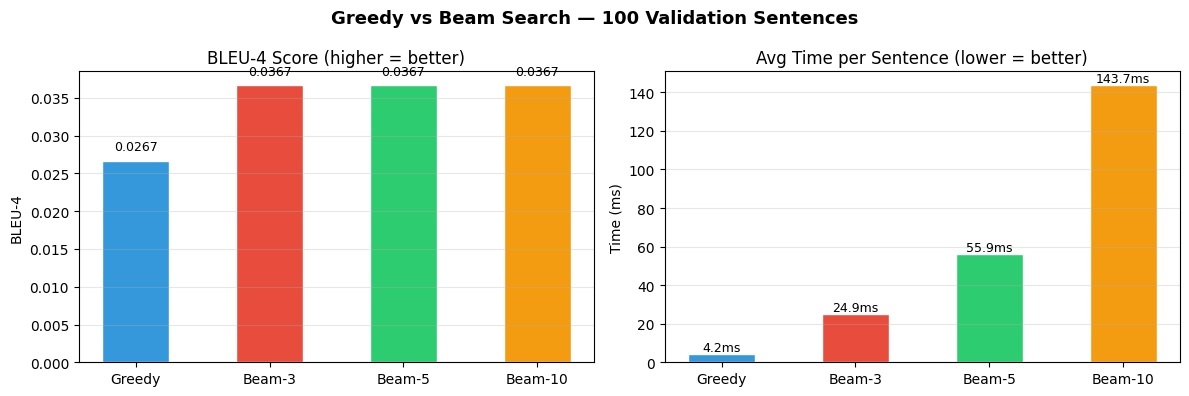

In [11]:
names  = list(comparison_results.keys())
bleu4s = [comparison_results[n]['bleu4'] for n in names]
times  = [comparison_results[n]['time'] * 1000 for n in names]   # ms

colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Greedy vs Beam Search — 100 Validation Sentences', fontsize=13, fontweight='bold')

# BLEU-4 bar chart
bars = axes[0].bar(names, bleu4s, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, bleu4s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('BLEU-4 Score (higher = better)')
axes[0].set_ylabel('BLEU-4'); axes[0].grid(axis='y', alpha=0.3)

# Time bar chart
bars2 = axes[1].bar(names, times, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}ms', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Avg Time per Sentence (lower = better)')
axes[1].set_ylabel('Time (ms)'); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

## 12. Translation Examples — Greedy vs Beam-5 vs Reference
5 concrete examples including cases where beam search helped (and possibly one where greedy was better).

In [12]:
# Pick 5 interesting examples from the 100-sentence eval set
# We compute BLEU improvement for each sentence and pick diverse cases

example_results = []

for eng, rus in eval_100:
    g_out  = greedy_translate(eng, model, eng_vocab, rus_vocab)
    b5_out = beam_search_translate(eng, model, eng_vocab, rus_vocab, beam_width=5)
    g_bleu  = bleu_score(g_out.split(),  rus.split(), max_n=4)
    b5_bleu = bleu_score(b5_out.split(), rus.split(), max_n=4)
    diff = b5_bleu - g_bleu
    example_results.append({'eng': eng, 'ref': rus,
                             'greedy': g_out, 'beam5': b5_out,
                             'greedy_bleu': g_bleu, 'beam5_bleu': b5_bleu,
                             'diff': diff})

# Sort by improvement — pick top-3 beam improvements + 1 tie + 1 greedy win
sorted_by_diff  = sorted(example_results, key=lambda x: x['diff'], reverse=True)
selected = sorted_by_diff[:3]                          # beam clearly helped
selected += [min(example_results, key=lambda x: x['diff'])]  # greedy won or tie
selected += [example_results[len(example_results)//2]]        # median case

print('=' * 75)
print('  TRANSLATION EXAMPLES: Greedy vs Beam-5 vs Reference')
print('=' * 75)

for i, ex in enumerate(selected, 1):
    label = '✓ Beam helped' if ex['diff'] > 0.01 else ('✓ Greedy better' if ex['diff'] < -0.01 else '≈ Tied')
    print(f'\nExample {i}  [{label}]')
    print(f"  Source  (EN) : {ex['eng']}")
    print(f"  Reference(RU): {ex['ref']}")
    print(f"  Greedy   (RU): {ex['greedy']}   [BLEU-4: {ex['greedy_bleu']:.4f}]")
    print(f"  Beam-5   (RU): {ex['beam5']}   [BLEU-4: {ex['beam5_bleu']:.4f}]")

print('\n' + '=' * 75)

  TRANSLATION EXAMPLES: Greedy vs Beam-5 vs Reference

Example 1  [✓ Beam helped]
  Source  (EN) : i think tom is ok
  Reference(RU): я думаю том в порядке
  Greedy   (RU): я думаю в порядке   [BLEU-4: 0.0000]
  Beam-5   (RU): я думаю том в порядке   [BLEU-4: 1.0000]

Example 2  [≈ Tied]
  Source  (EN) : i gave you a book
  Reference(RU): я дал вам книгу
  Greedy   (RU): я дал тебе книгу   [BLEU-4: 0.0000]
  Beam-5   (RU): я дал тебе книгу   [BLEU-4: 0.0000]

Example 3  [≈ Tied]
  Source  (EN) : the cup was empty
  Reference(RU): в чашке было пусто
  Greedy   (RU): в был пуста   [BLEU-4: 0.0000]
  Beam-5   (RU): в комнате было пусто   [BLEU-4: 0.0000]

Example 4  [≈ Tied]
  Source  (EN) : i gave you a book
  Reference(RU): я дал вам книгу
  Greedy   (RU): я дал тебе книгу   [BLEU-4: 0.0000]
  Beam-5   (RU): я дал тебе книгу   [BLEU-4: 0.0000]

Example 5  [≈ Tied]
  Source  (EN) : take it upstairs
  Reference(RU): отнесите его наверх
  Greedy   (RU): отнеси его наверх   [BLEU-4: 0.0000]

## 13. Final Summary Table

In [13]:
print('=' * 60)
print('              FINAL RESULTS SUMMARY')
print('=' * 60)
print()
print('  BLEU on Full Validation Set (Greedy Decoding):')
print(f"  BLEU-1 : {bleu_results[1]:.4f}  ({bleu_results[1]*100:.2f}%)")
print(f"  BLEU-2 : {bleu_results[2]:.4f}  ({bleu_results[2]*100:.2f}%)")
print(f"  BLEU-4 : {bleu_results[4]:.4f}  ({bleu_results[4]*100:.2f}%)")
print()
print('  Decoding Comparison (100 sentences):')
print(f"  {'Method':<10} {'BLEU-4':>10} {'Time/sent':>12}")
print('  ' + '-' * 35)
for name, res in comparison_results.items():
    print(f"  {name:<10} {res['bleu4']:>10.4f} {res['time']*1000:>10.1f} ms")
print()
best_method = max(comparison_results, key=lambda n: comparison_results[n]['bleu4'])
print(f'  Best BLEU-4 : {best_method}')
print()
print('  Key Insights:')
print('  • Beam search explores multiple hypotheses simultaneously')
print('  • Log-probabilities prevent numerical underflow during scoring')
print('  • Wider beam = better quality but slower (more candidates)')
print('  • Brevity penalty in BLEU prevents rewarding short outputs')
print('=' * 60)

              FINAL RESULTS SUMMARY

  BLEU on Full Validation Set (Greedy Decoding):
  BLEU-1 : 0.5094  (50.94%)
  BLEU-2 : 0.2645  (26.45%)
  BLEU-4 : 0.0279  (2.79%)

  Decoding Comparison (100 sentences):
  Method         BLEU-4    Time/sent
  -----------------------------------
  Greedy         0.0267        4.2 ms
  Beam-3         0.0367       24.9 ms
  Beam-5         0.0367       55.9 ms
  Beam-10        0.0367      143.7 ms

  Best BLEU-4 : Beam-3

  Key Insights:
  • Beam search explores multiple hypotheses simultaneously
  • Log-probabilities prevent numerical underflow during scoring
  • Wider beam = better quality but slower (more candidates)
  • Brevity penalty in BLEU prevents rewarding short outputs
